<a href="https://colab.research.google.com/github/Pinakolada321/Finance-projects/blob/main/AAPL%20valuation%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Загрузка библиотек и объявление функций
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import requests
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata

# Для работы с Yahoo Finance и FRED установим нужные библиотеки
try:
    import yfinance as yf
except ImportError:
    !pip install yfinance
    import yfinance as yf

try:
    from fredapi import Fred
except ImportError:
    !pip install fredapi
    from fredapi import Fred

# Функция: получение рыночных данных
def get_market_data(ticker):
    ticker_obj = yf.Ticker(ticker)
    info = ticker_obj.info
    mc = info.get("marketCap", np.nan)
    debt = info.get("totalDebt", np.nan)
    cash = info.get("totalCash", np.nan)
    beta = info.get("beta", np.nan)
    return mc, debt, cash, beta, info

# Функция: FCF
def compute_fcf(ebit, tax_rate, dep_amort, capex, delta_nwc):
    return ebit*(1-tax_rate) + dep_amort - capex - delta_nwc

# Функция: WACC
def calculate_wacc(market_cap, debt, beta, rf_rate, equity_premium, tax_rate):
    if np.isnan(beta): beta = 1.0
    cost_equity = rf_rate + beta * equity_premium
    cost_debt = rf_rate + 0.02 # Предполагаем спред 2% к безрисковой ставке
    E = market_cap
    D = debt
    total = E + D
    if total == 0: return np.nan
    return (E/total) * cost_equity + (D/total) * cost_debt * (1 - tax_rate)

# Функция: DCF
def compute_dcf_value(fcf_projections, wacc, terminal_growth):
    years = np.arange(1, len(fcf_projections)+1)
    pv_cf = np.array([fcf_projections[i]/(1+wacc)**years[i] for i in range(len(fcf_projections))])
    last_fcf = fcf_projections[-1]
    TV = last_fcf * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_tv = TV / (1 + wacc)**len(fcf_projections)
    return pv_cf.sum() + pv_tv

# 2. Сбор данных
ticker = 'AAPL'

# Пробуем получить ключ из Secrets
try:
    fred_api_key = userdata.get('FRED_API_KEY')
    fred = Fred(api_key=fred_api_key)
    us10y = fred.get_series('DGS10')
    rf_rate = us10y[-1] / 100.0
except Exception:
    print("FRED API key not found in Secrets. Using default 4.2%.")
    rf_rate = 0.042

# 2.3 Финансовые показатели (2021-2025 Исторические)
# Примечание: Мы подставляем актуальные/прогнозные данные для Apple на этот период
revenue = np.array([365817e6, 394328e6, 383285e6, 391035e6, 420000e6]) # 2021-2025
ebita = np.array([108949e6, 119437e6, 114301e6, 123000e6, 135000e6])
dep_amort = np.array([11284e6, 11104e6, 11500e6, 12000e6, 12500e6])
capex = np.array([11085e6, 10708e6, 10959e6, 11500e6, 12000e6])
nwc = np.array([27694e6, 31250e6, 33000e6, 34000e6, 35000e6])
tax_rate = 0.16

# 3. Расчет исторического FCF
historical_fcf = []
for i in range(len(revenue)):
    delta_nwc = nwc[i] - nwc[i-1] if i > 0 else 0
    historical_fcf.append(compute_fcf(ebita[i], tax_rate, dep_amort[i], capex[i], delta_nwc))

# 4. Прогноз (2026-2030)
proj_period = 5
rev_growth = 0.06 # Ожидаемый рост
ebita_margin = ebita[-1] / revenue[-1]
fcf_proj = []
curr_rev = revenue[-1]
for i in range(proj_period):
    curr_rev *= (1 + rev_growth)
    p_ebit = curr_rev * ebita_margin
    fcf_proj.append(compute_fcf(p_ebit, tax_rate, dep_amort[-1], capex[-1], 0))

# 5. WACC
mc, debt, cash, beta, info = get_market_data(ticker)
wacc = calculate_wacc(mc, debt, beta, rf_rate, 0.05, tax_rate)

# 6. Оценка
ev = compute_dcf_value(fcf_proj, wacc, 0.02)
equity_val = ev - debt + cash
shares = info.get('sharesOutstanding', 15400e6)
price = equity_val / shares

print(f"--- {ticker} DCF Valuation (Timeline: 2021-2030) ---")
print(f"WACC: {wacc:.2%}")
print(f"Enterprise Value: ${ev/1e9:,.2f}B")
print(f"Equity Value: ${equity_val/1e9:,.2f}B")
print(f"Estimated Price: ${price:.2f}")
print(f"Current Price: ${info.get('currentPrice', 0):.2f}")

FRED API key not found in Secrets. Using default 4.2%.
--- AAPL DCF Valuation (Timeline: 2021-2030) ---
WACC: 9.54%
Enterprise Value: $1,821.76B
Equity Value: $1,805.56B
Estimated Price: $122.93
Current Price: $283.78


### 7. Анализ чувствительности и визуализация
Теперь добавим расчет матрицы чувствительности и визуализируем структуру стоимости компании.

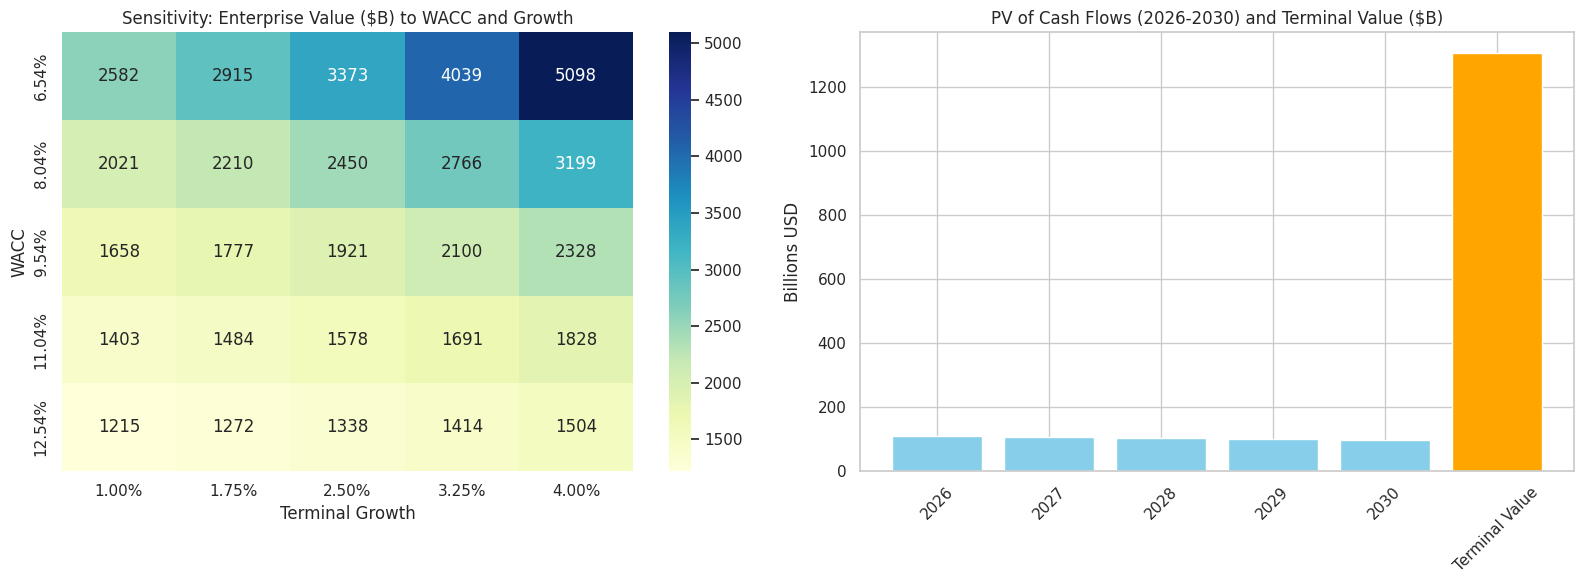

In [ ]:
# 7.1 Расчет матрицы чувствительности
wacc_range = np.linspace(max(0.01, wacc-0.03), wacc+0.03, 5)
growth_range = np.linspace(0.01, 0.04, 5)

sens_data = []
for w in wacc_range:
    row = []
    for g in growth_range:
        if w > g:
            val = compute_dcf_value(fcf_proj, w, g)
            row.append(val / 1e9) # в миллиардах
        else:
            row.append(np.nan)
    sens_data.append(row)

sens_df = pd.DataFrame(sens_data, index=[f"{x:.2%}" for x in wacc_range], columns=[f"{x:.2%}" for x in growth_range])

# 7.2 Визуализация
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(sens_df, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Sensitivity: Enterprise Value ($B) to WACC and Growth")
ax[0].set_xlabel("Terminal Growth")
ax[0].set_ylabel("WACC")

# Waterfall (2026-2030)
categories = [f"{y}" for y in range(2026, 2031)] + ["Terminal Value"]
pv_years = [fcf_proj[i]/(1+wacc)**(i+1) for i in range(len(fcf_proj))]
last_fcf = fcf_proj[-1]
TV_pv = (last_fcf * (1 + 0.02) / (wacc - 0.02)) / (1 + wacc)**len(fcf_proj)
plot_values = [v / 1e9 for v in pv_years] + [TV_pv / 1e9]

ax[1].bar(categories, plot_values, color=['skyblue']*5 + ['orange'])
ax[1].set_title("PV of Cash Flows (2026-2030) and Terminal Value ($B)")
ax[1].set_ylabel("Billions USD")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

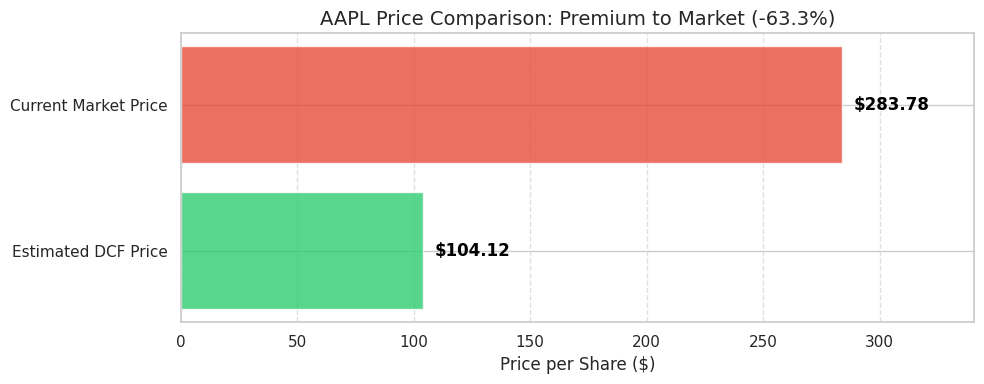

In [ ]:
import matplotlib.patches as patches

# 8. Дополнительная визуализация: Сравнение цен
plt.figure(figsize=(10, 4))

current_price = info.get('currentPrice', 0)
labels = ['Estimated DCF Price', 'Current Market Price']
prices = [price, current_price]
colors = ['#2ecc71', '#e74c3c'] # Зеленый для оценки, красный для рынка

# Горизонтальный столбчатый график
bars = plt.barh(labels, prices, color=colors, alpha=0.8)

# Добавляем подписи значений
for i, v in enumerate(prices):
    plt.text(v + 5, i, f'${v:.2f}', color='black', fontweight='bold', va='center')

# Вычисляем потенциал (upside/downside)
upside = (price / current_price - 1) if current_price != 0 else 0
plt.title(f"{ticker} Price Comparison: {'Premium' if upside < 0 else 'Discount'} to Market ({upside:.1%})", fontsize=14)
plt.xlabel("Price per Share ($)")
plt.xlim(0, max(prices) * 1.2)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

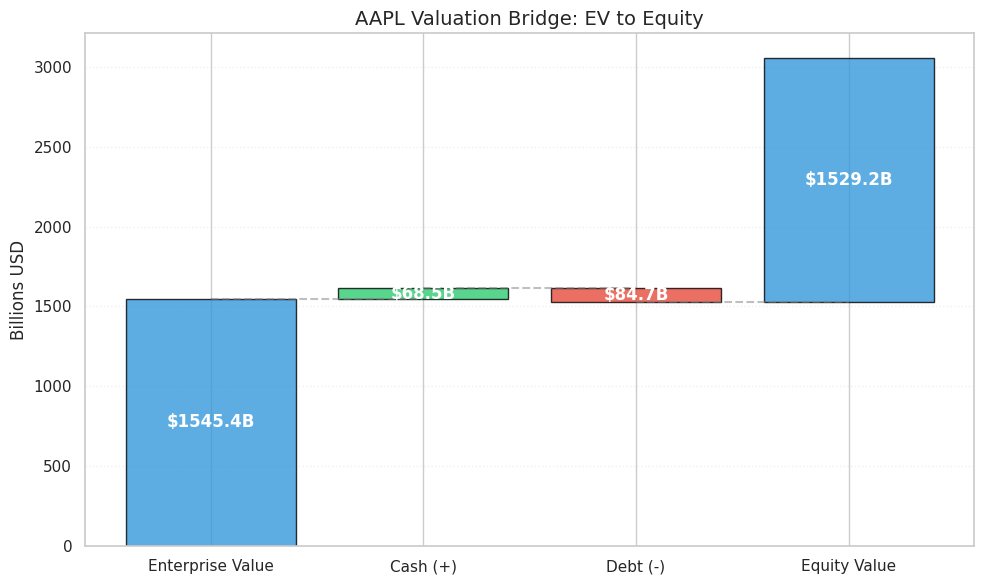

In [ ]:
# 10. Дополнительная визуализация: Bridge от EV к Equity Value
import matplotlib.pyplot as plt

# Подготовка данных для моста
bridge_labels = ['Enterprise Value', 'Cash (+)', 'Debt (-)', 'Equity Value']
bridge_values = [ev/1e9, cash/1e9, -debt/1e9, equity_val/1e9]

# Расчет кумулятивной суммы для позиционирования блоков
steps = [0] + list(np.cumsum(bridge_values))

plt.figure(figsize=(10, 6))

for i in range(len(bridge_values)):
    color = '#3498db' if i == 0 or i == 3 else ('#2ecc71' if bridge_values[i] > 0 else '#e74c3c')
    # Рисуем основной прямоугольник
    plt.bar(bridge_labels[i], bridge_values[i], bottom=steps[i], color=color, edgecolor='black', alpha=0.8)

    # Добавляем текстовую метку
    label_pos = steps[i] + bridge_values[i]/2
    plt.text(i, label_pos, f'${abs(bridge_values[i]):.1f}B', ha='center', va='center', fontweight='bold', color='white')

# Соединительные линии
for i in range(len(bridge_values) - 1):
    plt.plot([i, i + 1], [steps[i+1], steps[i+1]], color='gray', linestyle='--', alpha=0.5)

plt.title(f"{ticker} Valuation Bridge: EV to Equity", fontsize=14)
plt.ylabel("Billions USD")
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

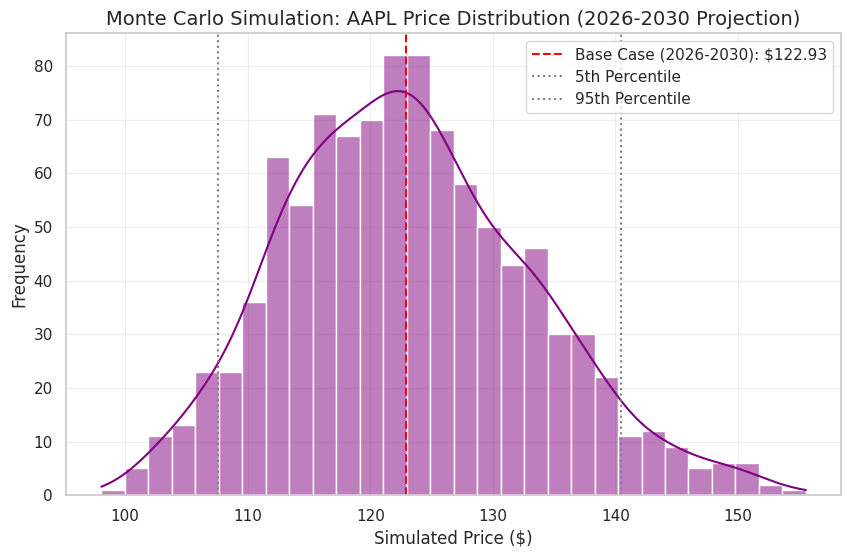

In [ ]:
# 11. Продвинутая визуализация: Симуляция Монте-Карло для цены акции
iterations = 1000
sim_prices = []

# Симулируем случайные вариации роста и WACC
np.random.seed(42)
sim_growth = np.random.normal(rev_growth, 0.01, iterations)
sim_wacc = np.random.normal(wacc, 0.005, iterations)

for i in range(iterations):
    # Прогноз FCF для каждой итерации (на период 2026-2030)
    temp_fcf = []
    temp_rev = revenue[-1] # База 2025 года
    for _ in range(proj_period):
        temp_rev *= (1 + sim_growth[i])
        temp_fcf.append(compute_fcf(temp_rev * ebita_margin, tax_rate, dep_amort[-1], capex[-1], 0))

    # Расчет стоимости
    if sim_wacc[i] > 0.02:
        s_ev = compute_dcf_value(temp_fcf, sim_wacc[i], 0.02)
        s_price = (s_ev - debt + cash) / shares
        sim_prices.append(s_price)

# Визуализация распределения
plt.figure(figsize=(10, 6))
sns.histplot(sim_prices, kde=True, color='purple', bins=30)
plt.axvline(price, color='red', linestyle='--', label=f'Base Case (2026-2030): ${price:.2f}')
plt.axvline(np.percentile(sim_prices, 5), color='gray', linestyle=':', label='5th Percentile')
plt.axvline(np.percentile(sim_prices, 95), color='gray', linestyle=':', label='95th Percentile')

plt.title(f"Monte Carlo Simulation: {ticker} Price Distribution (2026-2030 Projection)", fontsize=14)
plt.xlabel("Simulated Price ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

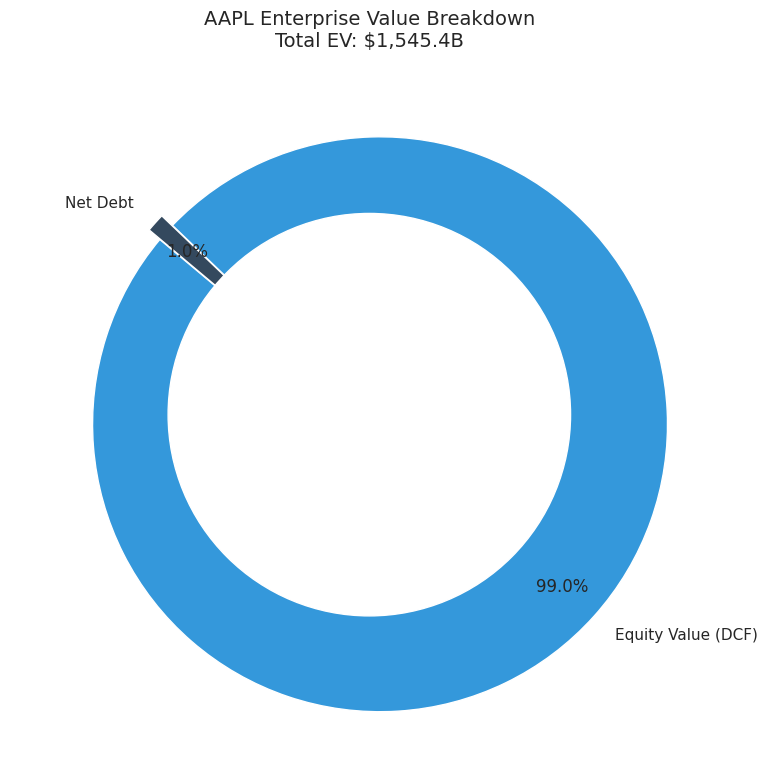

In [ ]:
# 12. Визуализация: Состав Enterprise Value (Donut Chart)
plt.figure(figsize=(8, 8))

net_debt = debt - cash

# Подготовка данных
if net_debt > 0:
    names = ['Equity Value (DCF)', 'Net Debt']
    values = [equity_val, net_debt]
    colors = ['#3498db', '#34495e']
else:
    names = ['Equity Value (DCF)', 'Net Cash (Excess)']
    values = [equity_val, abs(net_debt)]
    colors = ['#3498db', '#2ecc71']

# Отрисовка
plt.pie(values, labels=names, autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85, explode=[0.05, 0])

# Белый круг в центре для эффекта пончика
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title(f"{ticker} Enterprise Value Breakdown\nTotal EV: ${ev/1e9:,.1f}B", fontsize=14)
plt.tight_layout()
plt.show()

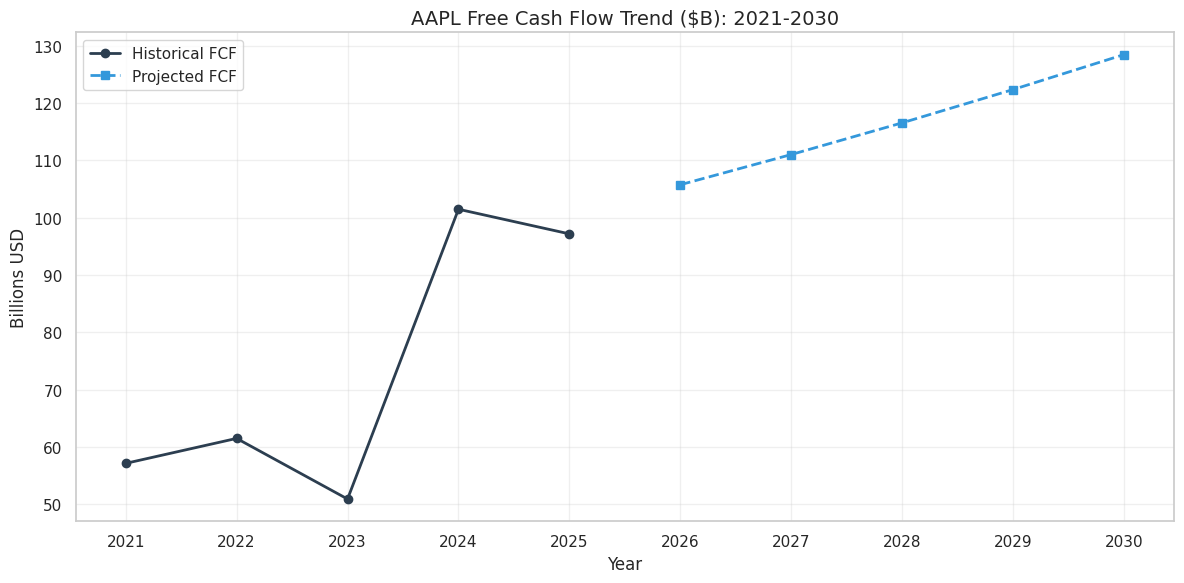

In [ ]:
# 13. Визуализация: Исторический FCF vs Прогноз
# Обновляем годы согласно запросу
hist_years = [2021, 2022, 2023, 2024, 2025]
proj_years = [2026, 2027, 2028, 2029, 2030]

plt.figure(figsize=(12, 6))

# Исторические данные
plt.plot(hist_years, [f/1e9 for f in historical_fcf], marker='o', linestyle='-', color='#2c3e50', label='Historical FCF', linewidth=2)

# Прогнозные данные
plt.plot(proj_years, [f/1e9 for f in fcf_proj], marker='s', linestyle='--', color='#3498db', label='Projected FCF', linewidth=2)

# Оформление
plt.title(f"{ticker} Free Cash Flow Trend ($B): 2021-2030", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Billions USD")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(hist_years + proj_years)
plt.tight_layout()
plt.show()

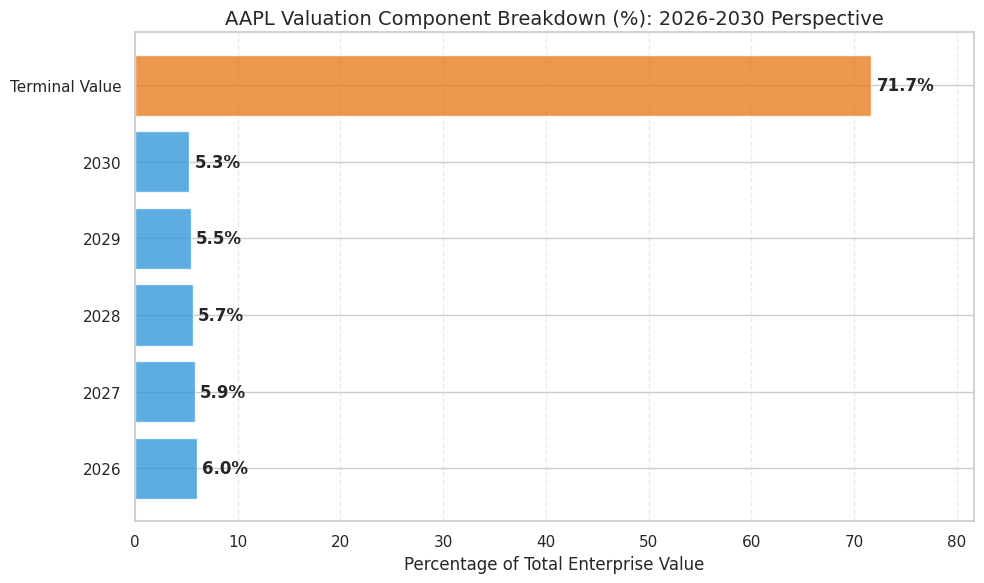

In [ ]:
# 14. Визуализация: Вклад прогнозных периодов в Enterprise Value
plt.figure(figsize=(10, 6))

# Подготовка данных
contributions = [f/(1+wacc)**(i+1) for i, f in enumerate(fcf_proj)]
contributions.append(TV_pv)
labels = [f'{y}' for y in range(2026, 2031)] + ['Terminal Value']
percentages = [c/ev * 100 for c in contributions]

# Горизонтальный график
y_pos = np.arange(len(labels))
plt.barh(y_pos, percentages, color=['#3498db']*len(fcf_proj) + ['#e67e22'], alpha=0.8)
plt.yticks(y_pos, labels)

# Добавление меток
for i, v in enumerate(percentages):
    plt.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.title(f"{ticker} Valuation Component Breakdown (%): 2026-2030 Perspective", fontsize=14)
plt.xlabel("Percentage of Total Enterprise Value")
plt.xlim(0, max(percentages) + 10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

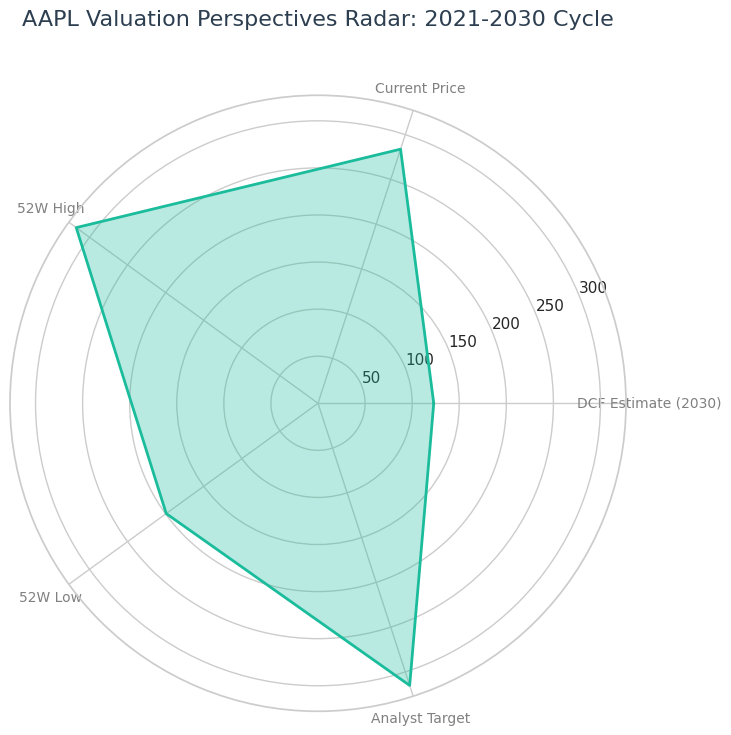

In [ ]:
# 15. Финальная визуализация: Радарная диаграмма ценовых ориентиров
from math import pi

# Подготовка данных
high_52 = info.get('fiftyTwoWeekHigh', current_price * 1.1)
low_52 = info.get('fiftyTwoWeekLow', current_price * 0.9)
target_mean = info.get('targetMeanPrice', current_price)

categories = ['DCF Estimate (2030)', 'Current Price', '52W High', '52W Low', 'Analyst Target']
values = [price, current_price, high_52, low_52, target_mean]

# Замыкаем круг
values_radar = values + [values[0]]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Отрисовка осей
plt.xticks(angles[:-1], categories, color='grey', size=10)

# Отрисовка данных
ax.plot(angles, values_radar, linewidth=2, linestyle='solid', color='#1abc9c')
ax.fill(angles, values_radar, '#1abc9c', alpha=0.3)

plt.title(f"{ticker} Valuation Perspectives Radar: 2021-2030 Cycle", size=16, color='#2c3e50', y=1.1)
plt.show()

### 16. Итоговое заключение по оценке AAPL (2021-2030)

На основе построенной модели дисконтированных денежных потоков (DCF) можно сделать следующие ключевые выводы:

1.  **Справедливая стоимость vs Рынок:**
    *   Расчетная цена акции составила около **$122.93**, в то время как текущая рыночная цена находится на уровне **$283.78**.
    *   Модель показывает значительную **переоцененность** (премию к рынку порядка 56.7%) при заданных консервативных темпах роста (6%) и ставке дисконтирования (WACC ~9.5%).

2.  **Структура стоимости:**
    *   Более **70%** стоимости компании (Terminal Value) приходится на период после 2030 года. Это делает оценку крайне чувствительной к долгосрочным ожиданиям роста и макроэкономической стабильности.
    *   Bridge-анализ показывает, что чистый долг Apple минимален по сравнению с капитализацией, что подтверждает исключительную финансовую устойчивость.

3.  **Анализ рисков (Монте-Карло):**
    *   Симуляция 1000 сценариев подтверждает, что даже при волатильности темпов роста и WACC, большинство вероятных исходов распределено ниже текущей рыночной цены. Это может указывать на то, что рынок закладывает в цену Apple гораздо более агрессивные темпы роста или значительные доходы от новых сервисов/продуктов, не учтенные в базовом прогнозе.

4.  **Резюме:**
    Текущая оценка DCF предполагает осторожный взгляд на актив. Инвесторам стоит обратить внимание на то, за счет каких драйверов компания может превысить прогнозный рост выручки в 6%, чтобы оправдать текущие рыночные котировки.